# Notebook 01 - Exploration du dataset

Nous avons pour objectif de comprendre la structure du dataset avant de commencer le suivi. Cette ?tape permet de v?rifier les images disponibles, les annotations et les fichiers qui indiquent les occultations ou les sorties du champ de vision.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence
from src.visualization import show_frames_grid, draw_bbox

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Chargement de la sequence

Nous avons une sequence d'images dans `data/car/car-11/img`. Nous commen?ons par lister les fichiers afin de connaitre le nombre de frames disponibles.

In [2]:
image_paths = load_image_sequence(IMG_DIR)
print(f"Nombre d'images: {len(image_paths)}")
print("Premiere image:", image_paths[0].name)
print("Derniere image:", image_paths[-1].name)

Nombre d'images: 1661
Premiere image: 00000001.jpg
Derniere image: 00001661.jpg


Nous observons le nombre total d'images. Cela nous donne la dur?e de la s?quence en frames.

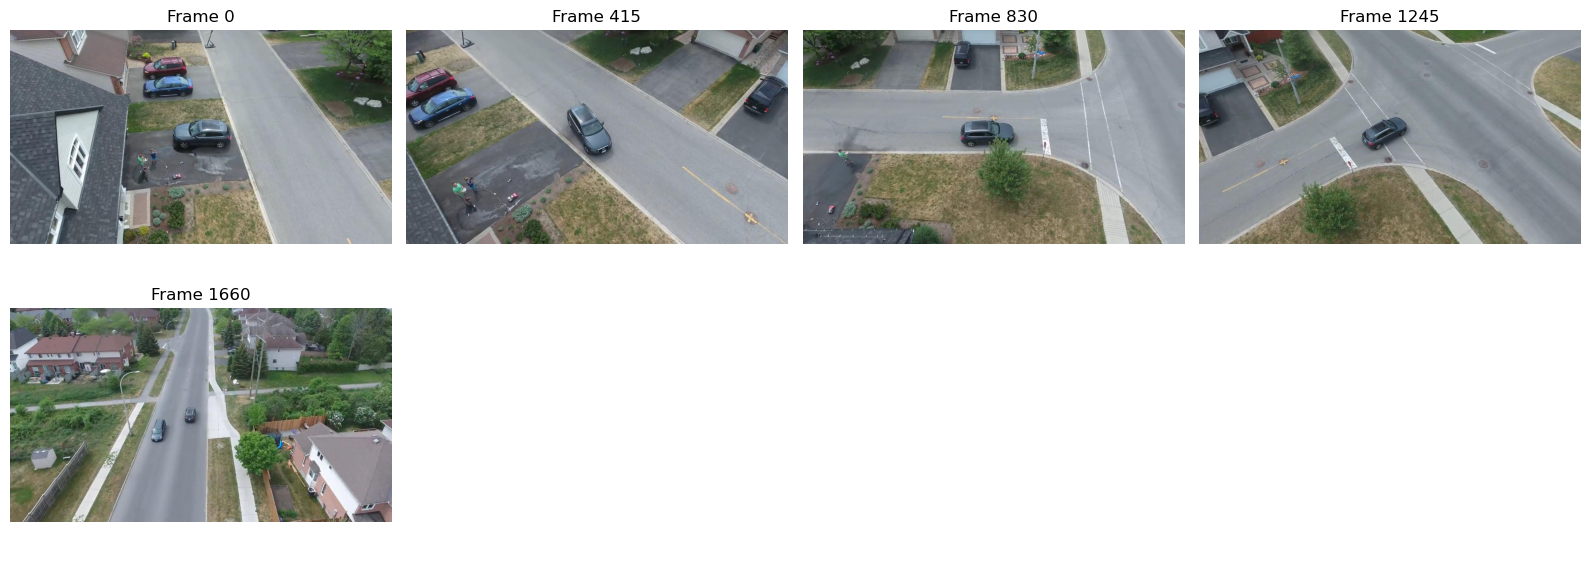

In [3]:
indices = [0, len(image_paths)//4, len(image_paths)//2, 3*len(image_paths)//4, len(image_paths)-1]
frames = [load_image(image_paths[i]) for i in indices]
titles = [f"Frame {i}" for i in indices]
fig = show_frames_grid(frames, titles)
plt.show()

Nous observons quelques frames de la sequence. Cette visualisation permet de confirmer que l'objet etudie est une voiture et que la sequence contient un mouvement exploitable.

## Lecture du groundtruth

Le fichier `groundtruth.txt` contient les bounding boxes annotees sous la forme `x, y, w, h`. Nous l'utilisons ici uniquement pour explorer le dataset et pour verifier visuellement les annotations. Il ne sera pas utilise comme methode principale de suivi.

In [4]:
gt_path = DATA_DIR / "groundtruth.txt"
gt_df = pd.read_csv(gt_path, header=None, names=["x", "y", "w", "h"])
gt_df["frame_id"] = range(len(gt_df))
gt_df.head()

,x,y,w,h,frame_id
0,543,305,202,91,0
1,544,301,199,90,1
2,544,301,197,89,2
3,544,300,196,91,3
4,543,302,197,89,4


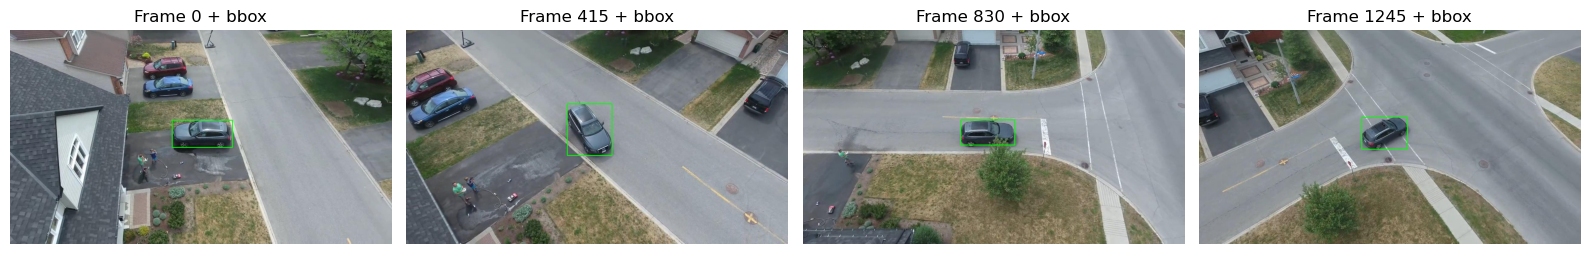

In [5]:
annotated_frames = []
annotated_titles = []
for i in indices[:4]:
    frame = load_image(image_paths[i])
    bbox = gt_df.loc[i, ["x", "y", "w", "h"]].tolist()
    annotated_frames.append(draw_bbox(frame, bbox))
    annotated_titles.append(f"Frame {i} + bbox")

fig = show_frames_grid(annotated_frames, annotated_titles)
plt.show()

Nous observons que les bounding boxes encadrent la voiture. Cette information sert seulement ? la verification visuelle et ? la comparaison finale.

## Fichiers full_occlusion et out_of_view

`full_occlusion.txt` indique les frames o? l'objet est totalement occult?. `out_of_view.txt` indique les frames o? l'objet sort du champ de vision. Ces fichiers aident ? comprendre les difficult?s potentielles du suivi.

In [6]:
full_occ = pd.read_csv(DATA_DIR / "full_occlusion.txt", header=None).iloc[0]
out_view = pd.read_csv(DATA_DIR / "out_of_view.txt", header=None).iloc[0]

print("Taille full_occlusion:", full_occ.shape)
print("Taille out_of_view:", out_view.shape)
print("Nombre de frames en full occlusion:", int(full_occ.sum()))
print("Nombre de frames out of view:", int(out_view.sum()))

Taille full_occlusion: (1661,)
Taille out_of_view: (1661,)
Nombre de frames en full occlusion: 0
Nombre de frames out of view: 0


Nous interpr?tons ces valeurs comme des indicateurs de frames difficiles. Dans ce projet, nous gardons une solution simple et nous analysons surtout la trajectoire estimee par nos points suivis.

## Conclusion

Nous avons v?rifi? que le dataset contient une s?quence d'images d'une voiture. Le fichier groundtruth sera utilis? uniquement pour la v?rification et la comparaison finale.